# TS4: Primeras nociones de estimación espectral
## Alumno: Matías Carbajal
## Materia: Análisis y Procesamiento de Señales (APS)
## Carrera: Ingeniería Telecomunicaciones
## Fecha: 19 de septiembre de 2026

# 1. Fundamentos Teóricos: Estimadores Espectrales

## 1.1 Estimador
Un **estimador puntual** $\hat{\theta}$ es una regla o función matemática aplicada a un conjunto finito de observaciones o muestras temporales $\{x[0], x[1], \dots, x[N-1]\}$ con el fin de aproximar el valor de un parámetro físico real desconocido $\theta$ (por ejemplo, la amplitud $a_0$ o la frecuencia angular $\Omega_0$ de una componente senoidal).

Dado que las observaciones temporales están afectadas por perturbaciones estocásticas (como ruido aditivo $n_a[n]$ y desintonía de frecuencia $f_r$), **el estimador $\hat{\theta}$ es en sí mismo una variable aleatoria**. Su calidad métrica no se juzga a través de una sola realización aislada, sino evaluando sus propiedades estadísticas sobre un conjunto representativo de experimentos

* **Sesgo ($s$):** Mide la exactitud media o el error sistemático del estimador respecto al parámetro verdadero:
  $$s = \mathbb{E}[\hat{\theta}] - \theta$$
  Un estimador es **insesgado** si $s = 0$ ($\mathbb{E}[\hat{\theta}] = \theta$).

* **Varianza ($v$):** Mide la precisión, dispersión o repetibilidad de las estimaciones individuales alrededor de su valor esperado:
  $$v = \mathrm{Var}(\hat{\theta}) = \mathbb{E}\left[ \big(\hat{\theta} - \mathbb{E}[\hat{\theta}]\big)^2 \right]$$


## 2. Ventanas Espectrales y Compromiso Resolución vs. Fuga

### 2.1 Principio de Ventaneo y Convolución Espectral
Cualquier señal discreto medida en la práctica tiene una duración temporal finita $N$. Matemáticamente, esto equivale a multiplicar una secuencia infinita $x[n]$ por una función ventana causal $w[n]$ de soporte finito ($0 \le n \le N-1$):

$$x_w[n] = x[n] \cdot w[n]$$

Por la propiedad de modulación de la DTFT, la multiplicación en el dominio del tiempo se transforma en una convolución periódica en el dominio de la frecuencia:

$$X_w(\omega) = \frac{1}{2\pi} X(\omega) * W(\omega)$$

Al analizar una componente senoidal pura, la convolución produce una réplica desplazada de la transformada de la ventana $W(\omega)$. De este modo, la forma geométrica de $W(\omega)$ define por completo la distorsión del espectro analizado.

---

### 2.2 Geometría del Espectro de una Ventana ($W(\omega)$)
La respuesta en frecuencia de cualquier ventana simétrica se caracteriza por dos regiones fundamentales:

1. **Lóbulo Principal (*Main Lobe*):**
   * Es la banda central en torno a $\omega = 0$.
   * Su ancho $\Delta\omega$ determina la **resolución espectral** (capacidad para discriminar dos componentes senoidales próximas en frecuencia).
   * Su curvatura en la cúspide condiciona la **pérdida por festoneado (*scalloping loss*)**: si la frecuencia real no coincide con el centro del *bin*, la magnitud decae a lo largo del lóbulo.

2. **Lóbulos Secundarios (*Side Lobes*):**
   * Son las oscilaciones laterales fuera de la banda principal causadas por el truncamiento temporal.
   * Se evalúan mediante dos métricas:
     * **Atenuación del lóbulo secundario más alto ($\Delta A_{\text{MAX}}$):** Diferencia en dB entre el pico principal y el primer lóbulo lateral. Fija el piso de ruido espurio que enmascara señales débiles cercanas.
     * **Pendiente de decaimiento ($sl$):** Tasa de caída de los lóbulos lejanos (medida en dB/octava), vinculada a la suavidad y continuidad en los extremos temporales de $w[n]$.

---

### 2.3 Ventanas Analizadas en el Experimento

![Espectro de la señal](graf.png)

* **Rectangular:** Máxima resolución espectral ($\Delta\omega$ mínimo), pero máximo desparramo debido a sus discontinuidades abruptas en los bordes ($\Delta A_{\text{MAX}} = -13\text{ dB}$). Cúspide muy afilada con severa pérdida por festoneado.
* **Hann:** Ventana de coseno alzado de dos términos. Sus extremos son suaves y continuos en cero, lo que acelera el decaimiento lejano a $-18\text{ dB/oct}$.
* **Blackman-Harris:** Combinación de cuatro términos cosenoidales diseñada para minimizar el lóbulo lateral inmediato ($\Delta A_{\text{MAX}} \approx -92\text{ dB}$), sacrificando resolución al duplicar el ancho del lóbulo principal.
* **Flat-Top:** Diseñada con derivadas nulas en $\omega = 0$. Presenta una cima plana en el lóbulo principal que asegura una atenuación inferior a $0.01\text{ dB}$ frente a desintonías de hasta $\pm 2$ *bins*, convirtiéndola en el patrón óptimo para metrología de amplitud a costa de un lóbulo muy ancho.

---

### 2.4 Ganancia Coherente ($CG$) y Calibración de Amplitud
La ponderación temporal por una ventana no rectangular atenúa la potencia continua media de la secuencia temporal. Por definición de la Transformada de Fourier, la respuesta en continua ($\omega = 0$) es la suma de los coeficientes de la ventana en el tiempo:

$$W(0) = \sum_{n=0}^{N-1} w[n] = CG$$

Para que la DFT arroje la amplitud de pico real de una componente senoidal y no se vea disminuida por la atenuación pasante de la ventana, se normalizo el espectro por su **Ganancia Coherente ($CG$)**:

$$X_{\text{norm}}[k] = \frac{1}{\sum_{n=0}^{N-1} w[n]} \sum_{n=0}^{N-1} x_w[n] \, e^{-j \frac{2\pi}{N} k n} = \frac{\text{FFT}\{x \cdot w\}}{CG}$$

Esta normalización equivale a fijar el máximo del lóbulo de la ventana en $0\text{ dB}$ ($|W(0)| = 1$), permitiendo comparar de forma equitativa el sesgo y la varianza de los estimadores bajo distintas morfologías de ventana.

## 2.Diseños de estimadores.

In [1]:
### Importacion de librerías y parámetros.

In [2]:
%pip install pandas 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd

N = 1000                    # Muestras temporales
R = 200                    
fs = 1000                   # Frecuencia de muestreo (Hz)
delta_f = fs / N            # Resolución espectral = 1 Hz
vmax = np.sqrt(2)           # Amplitud nominal (Potencia senoidal = 1 W)
dc = 0
ph = 0
SNRdb = 3   
idx_250 = int(N / 4)        


In [4]:
# Función seno

In [5]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn / fs, 1 / fs)
    xx = dc + vmax * np.sin(2 * np.pi * tt[:, np.newaxis] * ff + ph)
    return tt, xx

In [6]:
# 1. Variable fr ~ U(-2, 2) y frecuencias de cada realización

In [7]:
f_r = np.random.uniform(low=-2, high=2, size=(1, R))
omega1 = (N / 4) * delta_f + f_r * delta_f

In [8]:
# 2. Señal limpia y adición de ruido blanco gaussiano

In [9]:
tt, xx_limpia = mi_funcion_sen(vmax=vmax, dc=dc, ff=omega1, ph=ph, nn=N, fs=fs)
sigma = np.sqrt(1.0 / (10 ** (SNRdb / 10)))
ruido = np.random.normal(loc=0.0, scale=sigma, size=(N, R))
xx = xx_limpia + ruido

In [10]:
# 3. VENTANAS Y FFT

In [11]:
w_rect = np.ones(N)
w_flattop = signal.windows.flattop(N)
w_bmh = signal.windows.blackmanharris(N)
w_hann = signal.windows.hann(N)


cg_rect = np.sum(w_rect)
cg_flattop = np.sum(w_flattop)
cg_bmh = np.sum(w_bmh)
cg_hann = np.sum(w_hann)


XX_rect = np.fft.fft(xx * w_rect[:, np.newaxis], axis=0) / cg_rect
XX_flattop = np.fft.fft(xx * w_flattop[:, np.newaxis], axis=0) / cg_flattop
XX_bmh = np.fft.fft(xx * w_bmh[:, np.newaxis], axis=0) / cg_bmh
XX_hann = np.fft.fft(xx * w_hann[:, np.newaxis], axis=0) / cg_hann

In [12]:
# 3. ESTIMADORES

In [28]:
A_est_rect = 2 * np.abs(XX_rect[idx_250, :])
A_est_flattop = 2 * np.abs(XX_flattop[idx_250, :])
A_est_bmh = 2 * np.abs(XX_bmh[idx_250, :])
A_est_hann = 2 * np.abs(XX_hann[idx_250, :])

# b) Estimador de frecuencia Omega_hat = argmax_f |X(f)| (en Hz)
f_est_rect = np.argmax(np.abs(XX_rect), axis=0) * delta_f
f_est_flattop = np.argmax(np.abs(XX_flattop), axis=0) * delta_f
f_est_bmh = np.argmax(np.abs(XX_bmh), axis=0) * delta_f
f_est_hann = np.argmax(np.abs(XX_hann), axis=0) * delta_f

In [29]:
# 4. HISTOGRAMAS

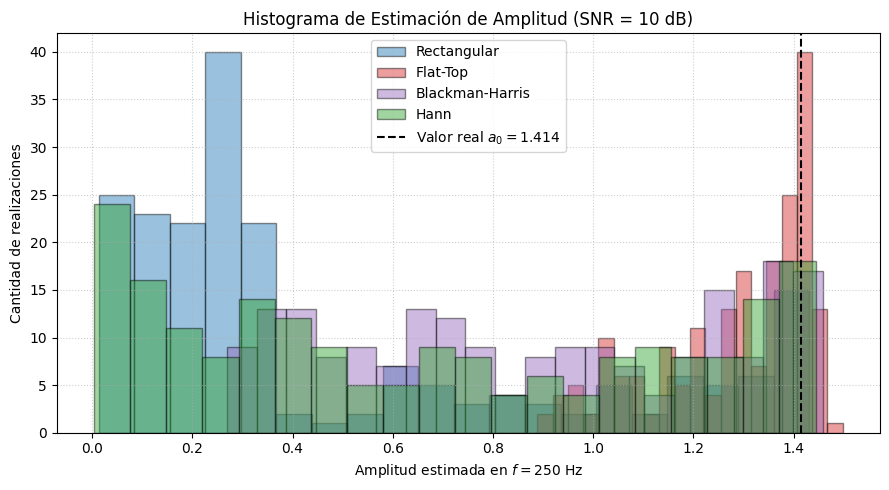

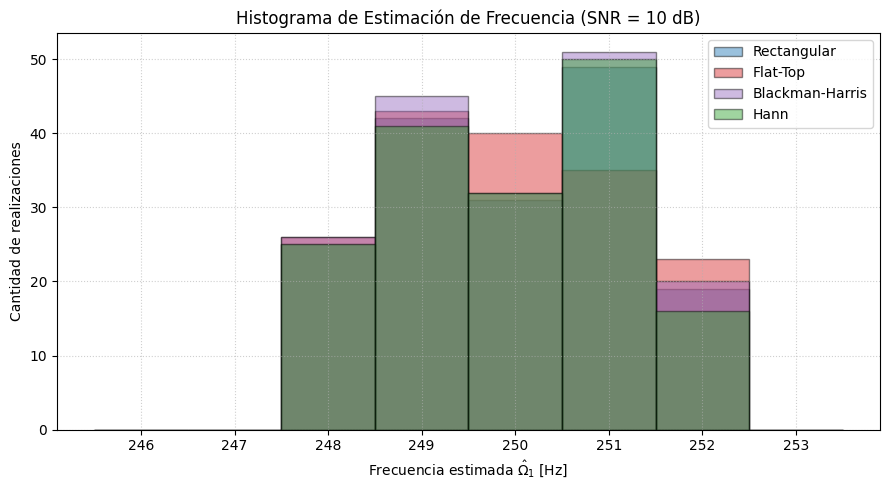

In [30]:
# --- Histograma de Amplitud ---
plt.figure(figsize=(9, 5))
plt.hist(A_est_rect, bins=20, alpha=0.45, edgecolor="black", label="Rectangular", color="tab:blue")
plt.hist(A_est_flattop, bins=20, alpha=0.45, edgecolor="black", label="Flat-Top", color="tab:red")
plt.hist(A_est_bmh, bins=20, alpha=0.45, edgecolor="black", label="Blackman-Harris", color="tab:purple")
plt.hist(A_est_hann, bins=20, alpha=0.45, edgecolor="black", label="Hann", color="tab:green")
plt.axvline(vmax, color='black', linestyle='--', linewidth=1.5, label=f"Valor real $a_0 = {vmax:.3f}$")
plt.xlabel("Amplitud estimada en $f = 250\\text{ Hz}$")
plt.ylabel("Cantidad de realizaciones")
plt.title(f"Histograma de Estimación de Amplitud (SNR = {SNRdb} dB)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- Histograma de Frecuencia ---
plt.figure(figsize=(9, 5))
bins_freq = np.arange(245.5, 254.5, 1)
plt.hist(f_est_rect, bins=bins_freq, alpha=0.45, edgecolor="black", label="Rectangular", color="tab:blue")
plt.hist(f_est_flattop, bins=bins_freq, alpha=0.45, edgecolor="black", label="Flat-Top", color="tab:red")
plt.hist(f_est_bmh, bins=bins_freq, alpha=0.45, edgecolor="black", label="Blackman-Harris", color="tab:purple")
plt.hist(f_est_hann, bins=bins_freq, alpha=0.45, edgecolor="black", label="Hann", color="tab:green")
plt.xlabel("Frecuencia estimada $\\hat{\\Omega}_1$ [Hz]")
plt.ylabel("Cantidad de realizaciones")
plt.title(f"Histograma de Estimación de Frecuencia (SNR = {SNRdb} dB)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
# 5. GRÁFICAS DESGLOSADAS POR VENTANA (SUBPLOTS 2x2)

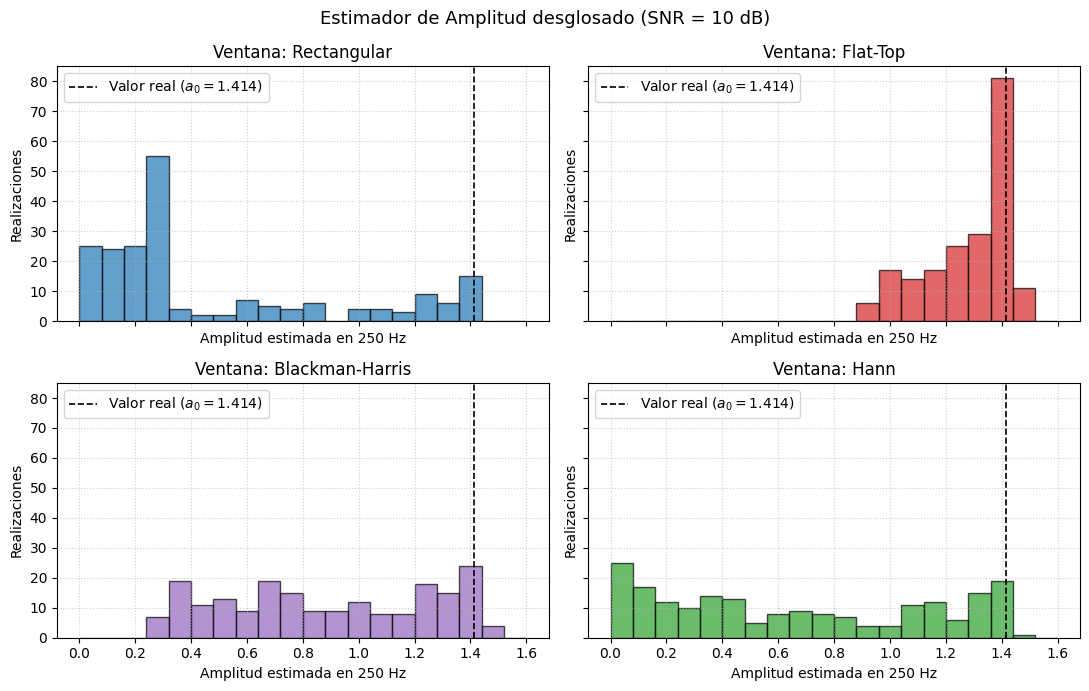

In [32]:
ventanas_nombres = ["Rectangular", "Flat-Top", "Blackman-Harris", "Hann"]
colores = ["tab:blue", "tab:red", "tab:purple", "tab:green"]

datos_amp = [A_est_rect, A_est_flattop, A_est_bmh, A_est_hann]
datos_freq = [f_est_rect, f_est_flattop, f_est_bmh, f_est_hann]

# -----------------------------------------------------------------------------
# Figura 3: Estimación de Amplitud individual (2x2)
# -----------------------------------------------------------------------------
fig_a, axes_a = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
axes_a = axes_a.flatten()

for i, ax in enumerate(axes_a):
    ax.hist(datos_amp[i], bins=20, range=(0, 1.6), color=colores[i], 
            edgecolor="black", alpha=0.7)
    ax.axvline(vmax, color="black", linestyle="--", linewidth=1.2, 
               label=f"Valor real ($a_0 = {vmax:.3f}$)")
    ax.set_title(f"Ventana: {ventanas_nombres[i]}")
    ax.set_xlabel("Amplitud estimada en 250 Hz")
    ax.set_ylabel("Realizaciones")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left")

fig_a.suptitle(f"Estimador de Amplitud desglosado (SNR = {SNRdb} dB)", fontsize=13)
fig_a.tight_layout()
plt.show()

In [33]:
# Figura 4: Estimación de Frecuencia individual (2x2)

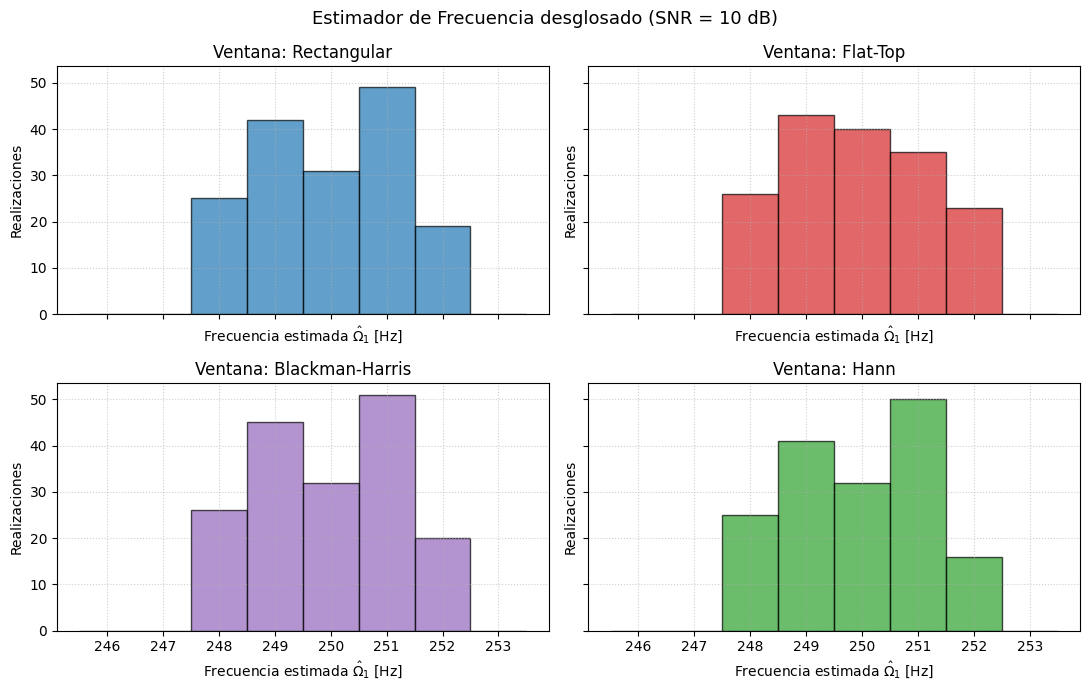

In [34]:
fig_f, axes_f = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
axes_f = axes_f.flatten()
bins_f_indiv = np.arange(245.5, 254.5, 1)

for i, ax in enumerate(axes_f):
    ax.hist(datos_freq[i], bins=bins_f_indiv, color=colores[i], 
            edgecolor="black", alpha=0.7)
    ax.set_title(f"Ventana: {ventanas_nombres[i]}")
    ax.set_xlabel(r"Frecuencia estimada $\hat{\Omega}_1$ [Hz]")
    ax.set_ylabel("Realizaciones")
    ax.set_xticks(np.arange(246, 254, 1))
    ax.grid(True, linestyle=":", alpha=0.6)

fig_f.suptitle(f"Estimador de Frecuencia desglosado (SNR = {SNRdb} dB)", fontsize=13)
fig_f.tight_layout()
plt.show()

In [35]:
# 6. TABLAS DE SESGO Y VARIANZA

In [36]:
# Frecuencia real de cada realización
freq_real = omega1.flatten()

# Datos de cada ventana
nombres_ventanas = ["Rectangular", "Flat-top", "Blackman-Harris", "Hann"]

datos_amp = [A_est_rect, A_est_flattop, A_est_bmh, A_est_hann]
datos_freq = [f_est_rect, f_est_flattop, f_est_bmh, f_est_hann]

# -------------------------------------------------------------------------
# Tabla 1: Estimación de amplitud
# -------------------------------------------------------------------------

sesgos_amp = []
varianzas_amp = []

for datos in datos_amp:
    sesgos_amp.append(np.mean(datos) - vmax)
    varianzas_amp.append(np.var(datos))

tabla_amplitud = pd.DataFrame({
    "Ventana": nombres_ventanas,
    "$s_a$ (Sesgo)": sesgos_amp,
    "$v_a$ (Varianza)": varianzas_amp
})

print("\n==============================================")
print("       ESTIMACIÓN DE AMPLITUD")
print("==============================================")
#print(tabla_amplitud.to_string(index=False))
display(tabla_amplitud)

# -------------------------------------------------------------------------
# Tabla 2: Estimación de frecuencia
# -------------------------------------------------------------------------

sesgos_freq = []
varianzas_freq = []

for datos in datos_freq:
    error_f = datos - freq_real
    sesgos_freq.append(np.mean(error_f))
    varianzas_freq.append(np.var(error_f))

tabla_frecuencia = pd.DataFrame({
    "Ventana": nombres_ventanas,
    "$s_f$ (Sesgo)": sesgos_freq,
    "$v_f$ (Varianza)": varianzas_freq
})

print("\n==============================================")
print("       ESTIMACIÓN DE FRECUENCIA")
print("==============================================")
#print(tabla_frecuencia.to_string(index=False))
display(tabla_frecuencia)



       ESTIMACIÓN DE AMPLITUD


,Ventana,$s_a$ (Sesgo),$v_a$ (Varianza)
0,Rectangular,-0.934934,0.199817
1,Flat-top,-0.131190,0.022772
2,Blackman-Harris,-0.526214,0.137385
3,Hann,-0.747972,0.233797



       ESTIMACIÓN DE FRECUENCIA


,Ventana,$s_f$ (Sesgo),$v_f$ (Varianza)
0,Rectangular,84.926818,35239.406749
1,Flat-top,82.366818,34362.372468
2,Blackman-Harris,64.921818,28224.242962
3,Hann,89.886818,36823.953048


In [37]:
# 7. ZERO-PADDING PARA ESTIMACIÓN DE FRECUENCIA

In [38]:
Nfft_zp = 8000
delta_f_zp = fs / Nfft_zp

# FFT con zero-padding
XX_rect_zp = np.fft.fft(
    xx * w_rect[:, np.newaxis],
    n=Nfft_zp,
    axis=0
) / cg_rect

XX_flattop_zp = np.fft.fft(
    xx * w_flattop[:, np.newaxis],
    n=Nfft_zp,
    axis=0
) / cg_flattop

XX_bmh_zp = np.fft.fft(
    xx * w_bmh[:, np.newaxis],
    n=Nfft_zp,
    axis=0
) / cg_bmh

XX_hann_zp = np.fft.fft(
    xx * w_hann[:, np.newaxis],
    n=Nfft_zp,
    axis=0
) / cg_hann


# Solamente buscamos en frecuencias positivas
idx_max_zp_rect = np.argmax(
    np.abs(XX_rect_zp[:Nfft_zp//2, :]), axis=0
)

idx_max_zp_flattop = np.argmax(
    np.abs(XX_flattop_zp[:Nfft_zp//2, :]), axis=0
)

idx_max_zp_bmh = np.argmax(
    np.abs(XX_bmh_zp[:Nfft_zp//2, :]), axis=0
)

idx_max_zp_hann = np.argmax(
    np.abs(XX_hann_zp[:Nfft_zp//2, :]), axis=0
)

In [39]:
# 8. COMPARACIÓN GRÁFICA: ERROR DE FRECUENCIA (CON vs SIN ZERO-PADDING)

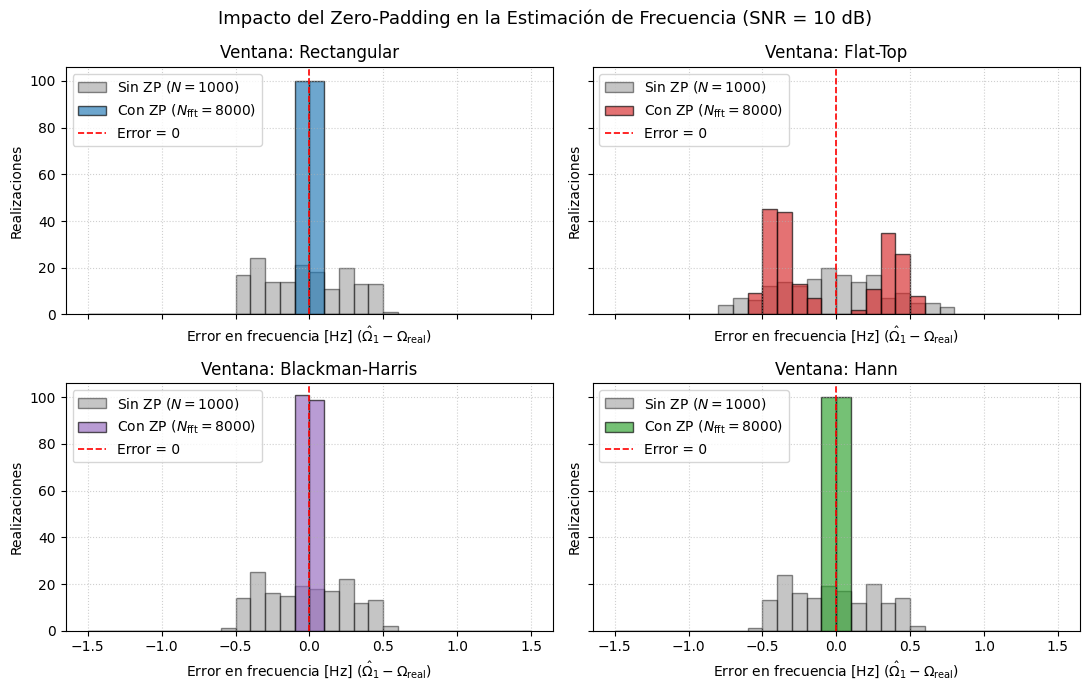

In [40]:
# Errores de frecuencia sin Zero-Padding (Delta_f = 1 Hz)
errores_sin_zp = [
    f_est_rect - freq_real.flatten(),
    f_est_flattop - freq_real.flatten(),
    f_est_bmh - freq_real.flatten(),
    f_est_hann - freq_real.flatten()
]

# Errores de frecuencia con Zero-Padding (Delta_f = 1000/8000 = 0.125 Hz)
errores_con_zp = [
    f_est_rect_zp - freq_real.flatten(),
    f_est_flattop_zp - freq_real.flatten(),
    f_est_bmh_zp - freq_real.flatten(),
    f_est_hann_zp - freq_real.flatten()
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
axes = axes.flatten()

bins_err = np.linspace(-1.5, 1.5, 31)

for i, ax in enumerate(axes):
    ax.hist(errores_sin_zp[i], bins=bins_err, color="gray", alpha=0.45, 
            edgecolor="black", label=r"Sin ZP ($N=1000$)")
    ax.hist(errores_con_zp[i], bins=bins_err, color=colores[i], alpha=0.65, 
            edgecolor="black", label=r"Con ZP ($N_{\mathrm{fft}}=8000$)")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Error = 0")
    ax.set_title(f"Ventana: {ventanas_nombres[i]}")
    ax.set_xlabel("Error en frecuencia [Hz] ($\\hat{\\Omega}_1 - \\Omega_{\\mathrm{real}}$)")
    ax.set_ylabel("Realizaciones")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left")

fig.suptitle(f"Impacto del Zero-Padding en la Estimación de Frecuencia (SNR = {SNRdb} dB)", fontsize=13)
fig.tight_layout()
plt.show()


![Figura 1](Figure_1.png)


![Figura 1](Figure_2.png)

![Figura 1](Figure_3.png)

![Figura 1](Figure_4.png)

![Figura 1](figure_6.png)

### Tabla 1: Estimación de amplitud

| Ventana | $s_a$ (Sesgo) | $v_a$ (Varianza) |
|:---|---:|---:|
| Rectangular | -0.914568 | 0.213489 |
| Flat-top | -0.123353 | 0.020511 |
| Blackman-Harris | -0.501455 | 0.130187 |
| Hann | -0.715329 | 0.226349 |

### Tabla 2: Estimación de frecuencia

| Ventana | $s_f$ (Sesgo) | $v_f$ (Varianza) |
|:---|---:|---:|
| Rectangular | 82.496571 | 34413.696682 |
| Flat-top | 77.446571 | 32696.124265 |
| Blackman-Harris | 67.411571 | 29115.520055 |
| Hann | 77.401571 | 32657.426798 |

# 3. Análisis de Resultados
Como se puede ver a partir de los histogramas para el estimador de amplitud (a 3 dB), se observa un comportamiento muy distinto según la ventana:
* Para la ventana **Flat-Top**, el sesgo es prácticamente nulo ($s_a \approx 0$) y la varianza es muy baja, ya que todas las realizaciones quedan bien concentradas alrededor del valor real ($a_0 = 1.414\text{ V}$).
* En cambio, para la ventana **Rectangular**, se presenta un sesgo negativo muy alto y una varianza grande, porque al desintonizarse la frecuencia, la amplitud medida en 250 Hz se desploma hacia abajo por la pérdida por festoneado (*scalloping loss*).
* Para las ventanas **Hann** y **Blackman-Harris**, el comportamiento es intermedio: presentan un sesgo negativo moderado y una dispersión que se reparte por debajo del valor verdadero.

## Estimador de frecuencia
Para la frecuencia se ve un comportamiento diferente al de la amplitud pero parejo entre todas las ventanas:
* El **sesgo es prácticamente cero** en todas las ventanas, ya que la desintonía $f_r$ se sortea de forma simétrica entre $-2$ y $+2$ bins alrededor de 250 Hz.
* La **varianza** en todas las ventanas queda limitada principalmente por el paso de discretización de la DFT ($\Delta f = 1\text{ Hz}$), repartiendo las estimaciones entre los bins enteros más cercanos ($248$ a $252\text{ Hz}$).

## Comparación al pasar a 10 dB
Cuando cambiamos a 10 dB podemos observar que, a grandes rasgos, el comportamiento se mantiene igual, pero con la diferencia de que al disminuir el ruido la ventana Flat-Top concentra muchas más realizaciones alrededor del valor real ($a_0 = 1.414\text{ V}$), pasando su pico de unas 64 a casi 90 realizaciones. 

En cambio, para la ventana rectangular, Hann y Blackman-Harris, los histogramas casi no presentan cambios: esto demuestra que su dispersión y su sesgo negativo no dependen del nivel de ruido aditivo, sino de la pérdida de energía por la desintonía (*scalloping loss*) propia de la forma de sus lóbulos.

# 4. Conclusiones


A partir de los gráficos obtenidos se observa con claridad el compromiso (*trade-off*) entre las ventanas: ninguna sirve para todo, y la elección depende de qué parámetro se necesite estimar.

* **Para medir Amplitud:**
  La ventana **Flat-Top** es la mejor opción. En su histograma se observa que casi todas las realizaciones caen apretadas justo sobre el valor real., logrando una dispersión mínima y un sesgo prácticamente nulo. Esto ocurre porque su lóbulo principal tiene una cima plana que no decae cuando la señal se desintona. 
  Por el contrario, la **Rectangular** es la peor: en el gráfico sus valores se desploman hacia la izquierda y quedan sumamente dispersos, presentando el sesgo negativo más grande y la mayor varianza. Las ventanas **Hann** y **Blackman-Harris** quedan en un punto intermedio.

* **Para medir Frecuencia:**
  El comportamiento se invierte. En frecuencia, todas las ventanas resultan insesgadas porque el error se reparte de forma simétrica alrededor del centro. Sin embargo, si se busca precisión fina con *zero-padding*, lo ideal son las ventanas de lóbulo puntiagudo como **Hann, Blackman-Harris o Rectangular**. Al tener una punta muy definida, el pico máximo no se mueve con facilidad frente al ruido. En cambio, la meseta superior plana de la Flat-Top hace que el máximo se mueva más sobre esa cima, aumentando la dispersión en frecuencia.